# Anomaly Detection Dataset Generation

`make_anomaly_dataset` generates a dataset where *normal* samples follow a
smooth signal built from the same primitives used in the classification
module, while *anomalous* samples deviate by a larger noise term on every
channel simultaneously.

The function returns three tensors:
- `x` — sampled input coordinates `(n_samples,)`, for plotting only
- `Y` — observed signal values `(n_samples, n_channels)`
- `labels` — `0` = normal, `1` = anomaly, shape `(n_samples,)`

This notebook demonstrates:
- A default single-channel sinusoidal + linear signal with 5% anomalies
- The effect of `anomaly_scale` on detectability
- A dataset built from a custom `channel_params` list
- Multi-channel output where anomalies affect all channels
- Basic PyTorch `DataLoader` integration

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from artificial_dataset import ClassifierMetrics, make_anomaly_dataset

## Default dataset: sinusoidal + linear signal with 5% anomalies

The default signal combines `sin(x) + 0.1 * x`. Normal samples cluster
tightly around the curve; anomalous samples scatter widely due to the
`anomaly_scale * noise_std` perturbation.

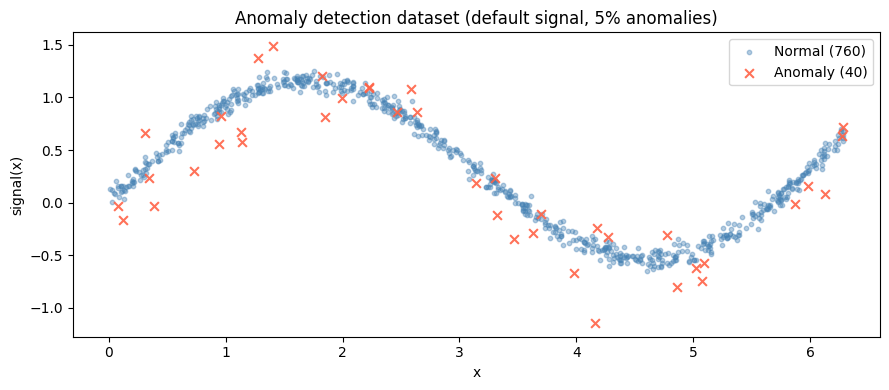

In [2]:
x, y, labels = make_anomaly_dataset(
    n_samples=800, anomaly_fraction=0.05, random_state=0
)

normal = labels == 0
anomaly = labels == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

## Effect of `anomaly_scale` on detectability

`anomaly_scale` multiplies `noise_std` for anomalous samples.
Small values make anomalies hard to distinguish; large values produce
clear outliers.

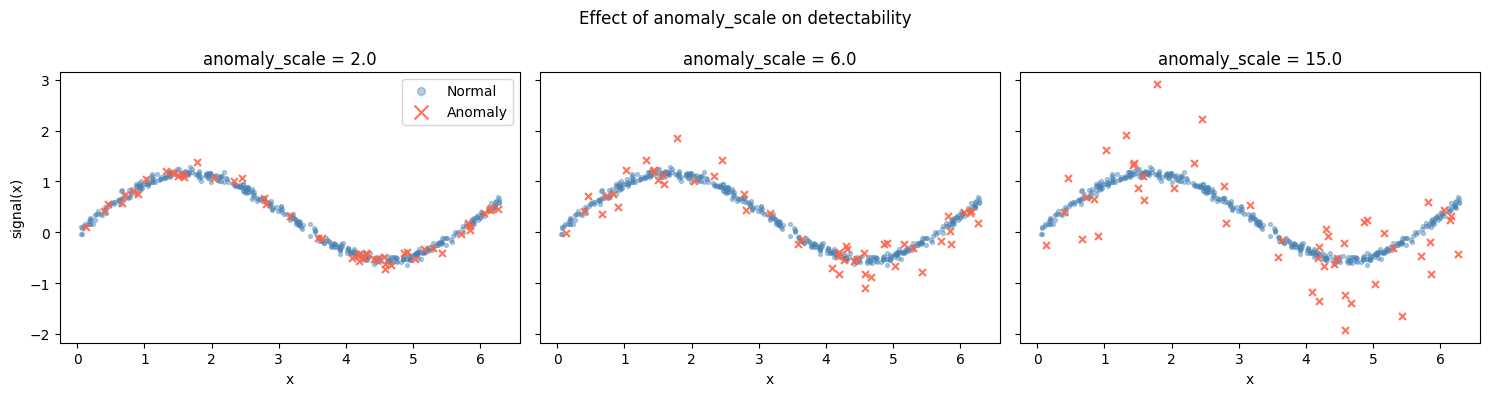

In [3]:
scales = [2.0, 6.0, 15.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, scale in enumerate(scales):
    x_s, y_s, labels_s = make_anomaly_dataset(
        n_samples=500, anomaly_fraction=0.1, anomaly_scale=scale, random_state=1
    )
    normal = labels_s == 0
    anomaly = labels_s == 1
    axes[i].scatter(
        x_s[normal],
        y_s[normal, 0],
        s=8,
        alpha=0.4,
        color="steelblue",
        label="Normal",
    )
    axes[i].scatter(
        x_s[anomaly],
        y_s[anomaly, 0],
        s=25,
        alpha=0.9,
        color="tomato",
        marker="x",
        label="Anomaly",
    )
    axes[i].set_title(f"anomaly_scale = {scale}")
    axes[i].set_xlabel("x")
axes[0].set_ylabel("signal(x)")
axes[0].legend(markerscale=2)
plt.suptitle("Effect of anomaly_scale on detectability")
plt.tight_layout()
plt.show()

## Custom signal shape: polynomial + sinusoidal

`channel_params` is a list of signal-parameter dicts — one per channel.
Any combination of `"linear"`, `"polynomial"`, and `"sinusoidal"` keys
can appear in each dict to define the underlying normal-behaviour pattern
for that channel.

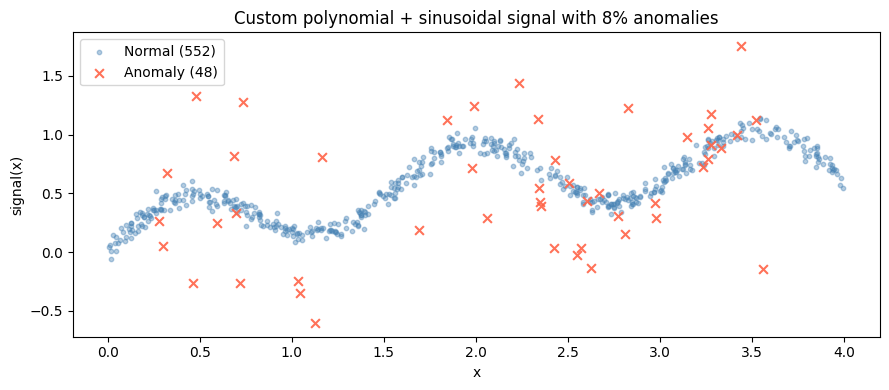

In [4]:
channel_params = [
    {
        "polynomial": {"coefficients": [0.0, 0.5, -0.1, 0.005]},
        "sinusoidal": {"amplitude": 0.3, "frequency": 4.0, "phase": 0.0},
    }
]

x_p, y_p, labels_p = make_anomaly_dataset(
    n_samples=600,
    anomaly_fraction=0.08,
    noise_std=0.05,
    x_range=(0.0, 4.0),
    channel_params=channel_params,
    anomaly_scale=8.0,
    random_state=2,
)

normal = labels_p == 0
anomaly = labels_p == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x_p[normal],
    y_p[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x_p[anomaly],
    y_p[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Custom polynomial + sinusoidal signal with 8% anomalies")
ax.legend()
plt.tight_layout()
plt.show()

## Multi-channel output

Pass a list with more than one entry to `channel_params` to get a `Y`
tensor with one column per channel.  Anomalies are injected with the
same scaled noise on every channel, so the anomaly label is consistent
across the whole row.

x shape      : torch.Size([600])
y shape      : torch.Size([600, 2])
labels shape : torch.Size([600])


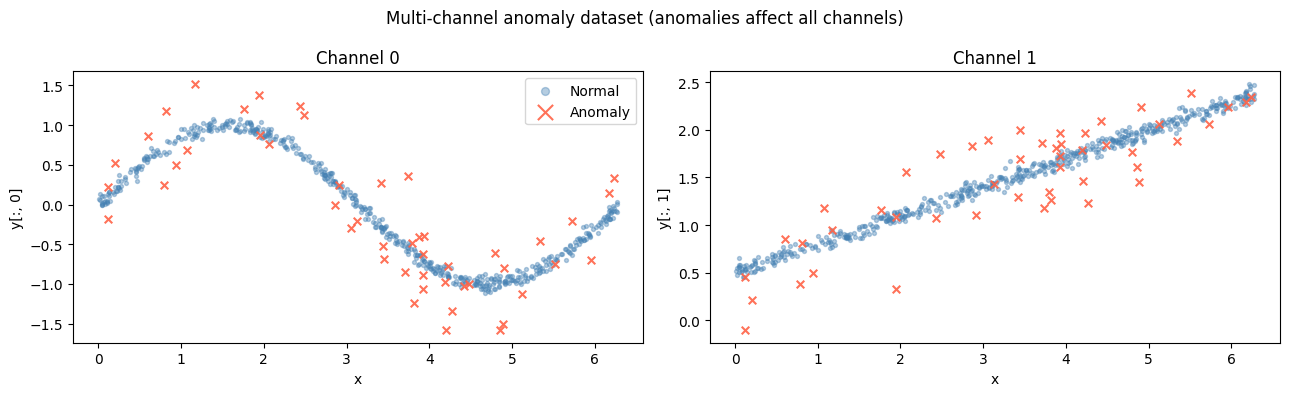

In [5]:
channel_params_mc = [
    {"sinusoidal": {"amplitude": 1.0, "frequency": 1.0, "phase": 0.0}},
    {"linear": {"slope": 0.3, "intercept": 0.5}},
]

x_mc, y_mc, labels_mc = make_anomaly_dataset(
    n_samples=600,
    anomaly_fraction=0.08,
    channel_params=channel_params_mc,
    anomaly_scale=6.0,
    random_state=4,
)

print(f"x shape      : {x_mc.shape}")
print(f"y shape      : {y_mc.shape}")
print(f"labels shape : {labels_mc.shape}")

normal = labels_mc == 0
anomaly = labels_mc == 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for ch, ax in enumerate(axes):
    ax.scatter(
        x_mc[normal],
        y_mc[normal, ch],
        s=8,
        alpha=0.4,
        color="steelblue",
        label="Normal",
    )
    ax.scatter(
        x_mc[anomaly],
        y_mc[anomaly, ch],
        s=30,
        alpha=0.9,
        color="tomato",
        marker="x",
        label="Anomaly",
    )
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("x")
    ax.set_ylabel(f"y[:, {ch}]")
axes[0].legend(markerscale=2)
plt.suptitle("Multi-channel anomaly dataset (anomalies affect all channels)")
plt.tight_layout()
plt.show()

## PyTorch `DataLoader` integration

Both generators return plain `torch.Tensor` objects and integrate directly
with `TensorDataset` and `DataLoader` for training loops.

In [6]:
x_dl, y_dl, labels_dl = make_anomaly_dataset(
    n_samples=1000, anomaly_fraction=0.05, random_state=3
)

dataset = TensorDataset(y_dl, labels_dl)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

batch_y, batch_labels = next(iter(loader))
print(f"Dataset size        : {len(dataset)}")
print(f"Batches per epoch   : {len(loader)}")
print(f"Batch y shape       : {batch_y.shape}")
print(f"Batch labels shape  : {batch_labels.shape}")
print(f"Normal in batch     : {(batch_labels == 0).sum().item()}")
print(f"Anomalies in batch  : {(batch_labels == 1).sum().item()}")

Dataset size        : 1000
Batches per epoch   : 16
Batch y shape       : torch.Size([64, 1])
Batch labels shape  : torch.Size([64])
Normal in batch     : 63
Anomalies in batch  : 1


## Evaluating a classifier with `ClassifierMetrics`

`ClassifierMetrics` computes accuracy, macro-averaged precision, recall,
F1 score, and a confusion matrix.

For anomaly detection, the most convenient entry point is
`ClassifierMetrics.from_anomaly_indices`, which accepts the *index positions*
of the positive (anomaly) class — no need to build a full label vector
manually.  A plain Python `list` or a `torch.Tensor` are both accepted.

In [7]:
# Generate a dataset and simulate a classifier that misses some anomalies
# and produces a few false positives.
x_ev, y_ev, labels_true = make_anomaly_dataset(
    n_samples=500, anomaly_fraction=0.1, random_state=10
)

true_indices = (labels_true == 1).nonzero(as_tuple=True)[0]

# Simulate predictions: keep 80% of true anomalies, add 5 false positives.
torch.manual_seed(0)
kept = true_indices[torch.randperm(len(true_indices))[: int(0.8 * len(true_indices))]]
false_positives = torch.tensor([1, 7, 23, 200, 350])
pred_indices = torch.cat([kept, false_positives])

m = ClassifierMetrics.from_anomaly_indices(
    n_samples=500,
    true_indices=true_indices,
    pred_indices=pred_indices,
)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}")
print(f"Recall    : {m.recall:.3f}")
print(f"F1 score  : {m.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(m.confusion_matrix)

Accuracy  : 0.970
Precision : 0.933
Recall    : 0.894
F1 score  : 0.913

Confusion matrix (rows = true, cols = predicted):
tensor([[445,   5],
        [ 10,  40]])
